In [1]:
from pathlib import Path

import numpy as onp
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
BASERESULTSDIR = Path("example_results/")

In [3]:
BASERESULTSDIR.is_dir()

True

In [4]:
QUANTITY = "forces"

In [5]:
ROOTNAMES = [
    "nonperiodic-exact",
    "nonperiodic-msm_rcut-3.0_p-4",
    "nonperiodic-msm_rcut-6.0_p-6",
]

In [6]:
# TODO: name something other than "rootname"? (de facto, what it is is the
#  algorithm/algorithm settings?)
ROOTNAMES_TO_LABELS = {
    "msm_rcut-3.0_p-4": "MSM, $r_{\mathrm{cut}} = 3 \overline{d}$, $p=4$",
    "msm_rcut-6.0_p-6": "MSM, $r_{\mathrm{cut}} = 6 \overline{d}$, $p=6$",
    "exact": "all pairs",
}

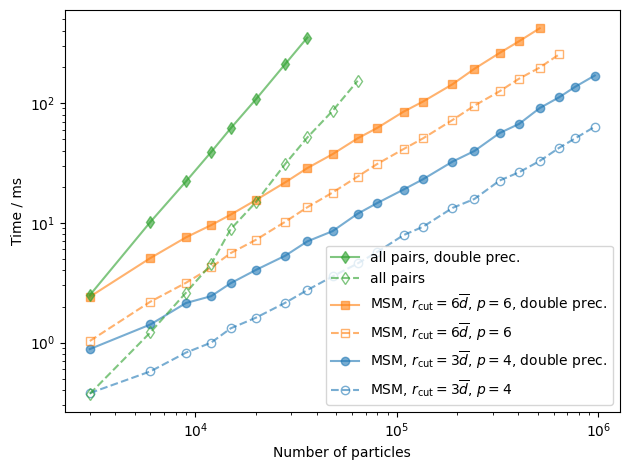

In [15]:
MARKERLIST = ["o", "s", "d"]
# plt.rcParams["font.size"] = 14    # TODO

# TODO: loop over this (also do "periodic")
PBCLABEL = "nonperiodic"

fig, ax = plt.subplots()
ax.set_xlabel("Number of particles")
ax.set_ylabel("Time / ms")
for rootname, marker in zip(ROOTNAMES_TO_LABELS, MARKERLIST):
    resultsdirname = PBCLABEL + "-" + rootname
    label = ROOTNAMES_TO_LABELS[rootname]
    for double_precision, linestyle, facecolor in zip(
        [False, True], ["--", "-"], ["none", None]
    ):
        color = None
        if double_precision:
            resultsdirname += "_doubleprec"
            label += ", double prec."
            color = lns[0].get_color()
        resultsdir = BASERESULTSDIR / resultsdirname
        results = pd.read_csv(resultsdir / "results.csv")
        particle_numbers = results["n_particles"].values
        times = results["time"].values
        lns = ax.plot(
            particle_numbers,
            1e3 * times,
            label=label,
            alpha=0.6,
            color=color,
            marker=marker,
            markerfacecolor=facecolor,
            linestyle=linestyle,
        )

ax.legend(reverse=True)

ax.set_xscale("log")
ax.set_yscale("log")
fig.tight_layout()
filename_without_suffix = f"scaling_{QUANTITY}_{PBCLABEL}" + "_loglog"
for suffix in [".png", ".pdf"]:
    fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))

ax.set_xscale("linear")
ax.set_yscale("linear")
fig.tight_layout()
ax.set_xlim(left=0.0)
ax.set_ylim(bottom=0.0)
filename_without_suffix = f"scaling_{QUANTITY}_{PBCLABEL}"
for suffix in [".png", ".pdf"]:
    fig.savefig(BASERESULTSDIR / (filename_without_suffix + suffix))